### MID model simulation

This is a (nearly) from-scratch refactor of the MID simulation code, after we discovererd odd behavior in the original

In [2]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
from poldracklab.fmri.spm_hrf import spm_hrf
import statsmodels.api as sm
import statsmodels.formula.api as smf


In [4]:

def get_subdata(sub, run, verbose=False):
    sub = str(sub).zfill(2)
    eventfile = f'AHRB/sub-{sub}/ses-1/func/sub-{sub}_ses-1_task-mid_run-0{run}_events.tsv'
    df = pd.read_csv(eventfile, sep='\t')
    if verbose:
        print(f'Loading {eventfile}')
        print(df.shape)
    assert df.shape[1] > 2, f'bad parsing'
    return df

events = get_subdata(1, 1)
events.tail()



,TRIAL_TYPE,CUE_ONSET,CUE_DURATION,FIXATION_ONSET,FIXATION_DURATION,PROBE_ONSET,PROBE_DURATION,FEEDBACK_ONSET,FEEDBACK_DURATION,TRIAL_RESULT,RESULT_REASON,PROBE_HIT,PROBE_MRT
45,NoMoneyStake,284.479,2,286.462,1.5,287.962,0.329,288.362,1.621,No money at stake!,You pressed too slow!,0,0
46,SmallLoss,289.978,2,291.961,1.5,293.461,0.329,293.861,1.621,You lose $0.20!,You pressed too slow!,0,0
47,SmallLoss,295.478,2,297.461,2.5,299.960,0.329,300.360,1.621,You keep $0.20!,Correct Response!,1,303
48,NoMoneyStake,301.976,2,303.959,3.0,306.959,0.369,307.409,1.581,No money at stake!,Correct Response!,1,303
49,SmallGain,308.975,2,310.958,2.0,312.958,0.369,313.408,1.581,You earn $0.20!,Correct Response!,1,304


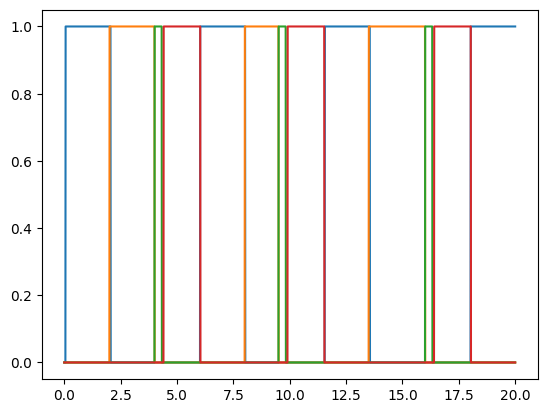

In [20]:
## create full design matrix with convolved regressors

def make_stick_function(onsets, durations, length, resolution=.01):
    """
    Create a stick function with onsets and durations

    Parameters
    ----------
    onsets : list
        List of onset times
    durations : list
        List of duration times
    length : float
        Length of the stick function (in seconds)
    resolution : float
        Resolution of the stick function (in seconds)
        0.1 secs by default
    
    Returns
    -------
    sf : np.array
        Timepoints of the stick function
    """
    timepoints = np.arange(0, length, resolution)
    sf = np.zeros_like(timepoints)
    for onset, duration in zip(onsets, durations):
        sf[(timepoints >= onset) & (timepoints < onset + duration)] = 1
    sf_df = pd.DataFrame({'sf': sf})
    sf_df.index = timepoints
    return sf_df

def create_design_matrix(events_df, resolution=resolution, hrf_length=32, verbose=False):
    # create the full design matrix
    maxtime = np.ceil(events_df['FEEDBACK_ONSET'].max() + events_df['FEEDBACK_DURATION'].values[-1])
    if verbose:
        print(f'Maxtime: {maxtime}')
    event_classes = ['CUE', 'FIXATION', 'PROBE', 'FEEDBACK']
    desmtx = pd.DataFrame()
    for event_class in event_classes:
        if verbose:
            print(f'Creating stick function for {event_class}')
        onsets = events_df[f'{event_class}_ONSET'].values
        durations = events_df[f'{event_class}_DURATION'].values
        desmtx[event_class]= make_stick_function(onsets, durations, maxtime)
    return desmtx

desmtx = create_design_matrix(events)
plt.plot(desmtx[:20])